In [1]:
# !pip install -q textblob emoji scikit-learn transformers

In [2]:
import os
import re
import random
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from IPython.display import clear_output  # Để xóa output cũ, vẽ hình mới (Live Update)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler # Mixed Precision (Tăng tốc độ, giảm VRAM)

from transformers import DistilBertTokenizerFast, DistilBertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

2025-12-25 01:37:35.467597: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766626655.654090      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766626655.707603      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766626656.145806      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766626656.145847      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766626656.145849      55 computation_placer.cc:177] computation placer alr

In [ ]:
# CONFIGURATION
RANDOM_SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
# Tối ưu cho 2 GPU T4: Tăng Batch Size lên 64 (hoặc 128 nếu model nhỏ)
BATCH_SIZE = 64  
NUM_EPOCHS = 2
LR = 2e-5
OUTPUT_DIR = "/kaggle/working"
NUM_WORKERS = 2  # Tận dụng CPU load data song song với GPU

os.makedirs(OUTPUT_DIR, exist_ok=True)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Device: {DEVICE}")
print(f"GPU Count: {torch.cuda.device_count()}")

Device: cuda
GPU Count: 2


In [ ]:
# PREPROCESSING UTILS
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def compute_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except Exception:
        return 0.0

In [ ]:
# DATASET
class SarcasmDataset(Dataset):
    def __init__(self, comments, parents, sentiments_comment, sentiments_parent, labels, tokenizer, max_len, mode='level1'):
        self.comments = comments
        self.parents = parents
        self.sent_c = sentiments_comment
        self.sent_p = sentiments_parent
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.mode = mode

    def __len__(self):
        return len(self.comments)

    def __getitem__(self, idx):
        comment = str(self.comments[idx])
        parent = str(self.parents[idx]) if self.parents is not None else ""
        item = {}

        if self.mode == 'level1':
            enc = self.tokenizer(comment, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
            item['input_ids'] = enc['input_ids'].squeeze(0)
            item['attention_mask'] = enc['attention_mask'].squeeze(0)
        else:
            enc_c = self.tokenizer(comment, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
            enc_p = self.tokenizer(parent, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
            item['input_ids_c'] = enc_c['input_ids'].squeeze(0)
            item['attention_mask_c'] = enc_c['attention_mask'].squeeze(0)
            item['input_ids_p'] = enc_p['input_ids'].squeeze(0)
            item['attention_mask_p'] = enc_p['attention_mask'].squeeze(0)

        if self.sent_c is not None and self.mode == 'level3':
            item['sent_c'] = torch.tensor(self.sent_c[idx], dtype=torch.float)
            item['sent_p'] = torch.tensor(self.sent_p[idx], dtype=torch.float)
        
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

def prepare_dataloaders(df_train, df_val, tokenizer, mode='level1', batch_size=BATCH_SIZE):
    # Prepare lists
    comments_tr = df_train['comment_pp'].tolist()
    parents_tr = df_train['parent_pp'].tolist() if 'parent_pp' in df_train.columns else [""]*len(comments_tr)
    y_tr = df_train['label'].values
    
    comments_val = df_val['comment_pp'].tolist()
    parents_val = df_val['parent_pp'].tolist() if 'parent_pp' in df_val.columns else [""]*len(comments_val)
    y_val = df_val['label'].values

    # Sentiments (chỉ dùng nếu có cột này)
    sent_c_tr = df_train['sentiment_comment'].values if 'sentiment_comment' in df_train.columns else None
    sent_p_tr = df_train['sentiment_parent'].values if 'sentiment_parent' in df_train.columns else None
    sent_c_val = df_val['sentiment_comment'].values if 'sentiment_comment' in df_val.columns else None
    sent_p_val = df_val['sentiment_parent'].values if 'sentiment_parent' in df_val.columns else None

    ds_tr = SarcasmDataset(comments_tr, parents_tr, sent_c_tr, sent_p_tr, y_tr, tokenizer, MAX_LEN, mode=mode)
    ds_val = SarcasmDataset(comments_val, parents_val, sent_c_val, sent_p_val, y_val, tokenizer, MAX_LEN, mode=mode)

    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return dl_tr, dl_val

In [ ]:
# MODELS
class DistilBertBaseline(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state[:,0,:] 
        return self.classifier(hidden).squeeze(-1)

class DualDistilBert(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    def forward(self, input_ids_c, attention_mask_c, input_ids_p, attention_mask_p):
        out_c = self.bert(input_ids=input_ids_c, attention_mask=attention_mask_c).last_hidden_state[:, 0]
        out_p = self.bert(input_ids=input_ids_p, attention_mask=attention_mask_p).last_hidden_state[:, 0]
        x = torch.cat([out_c, out_p], dim=1)
        return self.classifier(x).squeeze(-1)

class DualDistilBertWithSentiment(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.3):
        super().__init__()
        self.bert_c = DistilBertModel.from_pretrained(model_name)
        self.bert_p = DistilBertModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert_c.config.hidden_size * 2 + 3, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    def forward(self, input_ids_c, attention_mask_c, input_ids_p, attention_mask_p, sent_c, sent_p):
        o1 = self.bert_c(input_ids=input_ids_c, attention_mask=attention_mask_c).last_hidden_state[:,0,:]
        o2 = self.bert_p(input_ids=input_ids_p, attention_mask=attention_mask_p).last_hidden_state[:,0,:]
        sent_diff = (sent_c - sent_p).unsqueeze(1)
        sent_cat = torch.cat([sent_c.unsqueeze(1), sent_p.unsqueeze(1), sent_diff], dim=1)
        concat = torch.cat([o1, o2, sent_cat], dim=1)
        return self.classifier(concat).squeeze(-1)

In [ ]:
# ENGINE: TRAIN & EVAL (OPTIMIZED)
def train_epoch(model, dataloader, optimizer, scheduler, scaler):
    model.train()
    total_loss = 0.0
    step_losses = [] # Lưu loss chi tiết theo từng bước
    all_preds = []
    all_labels = []
    criterion = nn.BCEWithLogitsLoss()
    
    # Dùng enumerate để theo dõi số bước
    for step, batch in enumerate(tqdm(dataloader, desc="Training")):
        optimizer.zero_grad()
        labels = batch['labels'].to(DEVICE)
        
        # --- Mixed Precision Training ---
        with autocast():
            if 'input_ids' in batch:
                logits = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            else:
                input_ids_c = batch['input_ids_c'].to(DEVICE)
                attn_c = batch['attention_mask_c'].to(DEVICE)
                input_ids_p = batch['input_ids_p'].to(DEVICE)
                attn_p = batch['attention_mask_p'].to(DEVICE)
                
                if 'sent_c' in batch:
                    logits = model(input_ids_c, attn_c, input_ids_p, attn_p, 
                                   batch['sent_c'].to(DEVICE), batch['sent_p'].to(DEVICE))
                else:
                    logits = model(input_ids_c, attn_c, input_ids_p, attn_p)
            
            loss = criterion(logits, labels)

        # Backward với Scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        if scheduler:
            scheduler.step()
            
        # Logging
        current_loss = loss.item()
        total_loss += current_loss
        
        # Lưu loss mỗi 50 steps để vẽ biểu đồ chi tiết (tránh quá nặng nếu lưu full)
        if step % 50 == 0:
            step_losses.append(current_loss)

        preds = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    bin_preds = [1 if p>=0.5 else 0 for p in all_preds]
    acc = accuracy_score(all_labels, bin_preds)
    f1 = f1_score(all_labels, bin_preds)
    return avg_loss, acc, f1, step_losses

def eval_model(model, dataloader):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    criterion = nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            labels = batch['labels'].to(DEVICE)
            if 'input_ids' in batch:
                logits = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            else:
                input_ids_c = batch['input_ids_c'].to(DEVICE)
                attn_c = batch['attention_mask_c'].to(DEVICE)
                input_ids_p = batch['input_ids_p'].to(DEVICE)
                attn_p = batch['attention_mask_p'].to(DEVICE)
                if 'sent_c' in batch:
                    logits = model(input_ids_c, attn_c, input_ids_p, attn_p, 
                                   batch['sent_c'].to(DEVICE), batch['sent_p'].to(DEVICE))
                else:
                    logits = model(input_ids_c, attn_c, input_ids_p, attn_p)
            
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    bin_preds = [1 if p>=0.5 else 0 for p in all_preds]
    acc = accuracy_score(all_labels, bin_preds)
    f1 = f1_score(all_labels, bin_preds)
    return avg_loss, acc, f1, all_labels, all_preds

In [ ]:
# PLOTTING FUNCTIONS
def plot_detailed_history(history, step_losses, title="Model Training History"):
    plt.figure(figsize=(16, 6))
    
    # --- Biểu đồ 1: Loss theo Steps (Chi tiết) ---
    plt.subplot(1, 2, 1)
    plt.plot(step_losses, color='blue', alpha=0.3, label='Raw Step Loss')
    # Vẽ đường trung bình động (Moving Average) cho mượt
    window = 50
    if len(step_losses) > window:
        smooth_loss = np.convolve(step_losses, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(step_losses)), smooth_loss, color='red', linewidth=2, label='Smoothed Loss')
    
    plt.title(f'{title} - Training Loss (Detailed per 50 steps)')
    plt.xlabel('Steps (x50)')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # --- Biểu đồ 2: Metrics theo Epoch (Tổng quan) ---
    plt.subplot(1, 2, 2)
    epochs = range(1, len(history['val_f1']) + 1)
    plt.plot(epochs, history['train_acc'], 'b--o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-o', label='Val Acc')
    plt.plot(epochs, history['val_f1'], 'g-s', label='Val F1')
    
    # Hiển thị số liệu trên biểu đồ
    for x, y in zip(epochs, history['val_f1']):
        plt.text(x, y+0.002, f"{y:.4f}", ha='center', va='bottom', fontsize=9)

    plt.title(f'{title} - Metrics per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_final_evaluation(y_true, y_probs, title="Final Evaluation"):
    y_pred = [1 if p >= 0.5 else 0 for p in y_probs]
    
    plt.figure(figsize=(14, 6))
    
    # Confusion Matrix
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # ROC Curve
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title} - ROC Curve')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{title}_final_eval.png"))
    plt.show()
    
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred, digits=4))

In [ ]:
# Top-level run function per level
# ----------------------------
def run_level1(df, tokenizer):
    print("=== Level 1: DistilBERT baseline (comment only) ===")
    df_train, df_val = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED, stratify=df['label'])
    dl_tr, dl_val = prepare_dataloaders(df_train, df_val, tokenizer, mode='level1', batch_size=BATCH_SIZE)

    model = DistilBertBaseline().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(dl_tr) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps= int(0.1*total_steps), num_training_steps=total_steps)

    best_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        train_loss, train_acc, train_f1 = train_epoch_with_labels(model, dl_tr, optimizer, scheduler)
        val_loss, val_acc, val_f1, _, _ = eval_model_with_labels(model, dl_val)
        print(f"Train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f}")
        print(f"Val   loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "level1_distilbert.pt"))
    print("Best val F1:", best_f1)

def run_level2(df, tokenizer):
    print("=== Level 2: Dual DistilBERT (parent + comment) ===")
    # require parent_pp column
    df_train, df_val = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED, stratify=df['label'])
    dl_tr, dl_val = prepare_dataloaders(df_train, df_val, tokenizer, mode='level2', batch_size=BATCH_SIZE)

    model = DualDistilBert().to(DEVICE)
    if torch.cuda.device_count() > 1:
        print("Using", torch.cuda.device_count(), "GPUs")
        model = nn.DataParallel(model)
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(dl_tr) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps= int(0.1*total_steps), num_training_steps=total_steps)

    best_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        train_loss, train_acc, train_f1 = train_epoch_with_labels(model, dl_tr, optimizer, scheduler)
        val_loss, val_acc, val_f1, _, _ = eval_model_with_labels(model, dl_val)
        print(f"Train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f}")
        print(f"Val   loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(
                model.module.state_dict(),
                os.path.join(OUTPUT_DIR, "level2_dual_distilbert.pt")
                )
    print("Best val F1:", best_f1)

def run_level3(df, tokenizer):
    print("=== Level 3: Dual DistilBERT + Sentiment ===")
    df_train, df_val = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED, stratify=df['label'])
    dl_tr, dl_val = prepare_dataloaders(df_train, df_val, tokenizer, mode='level3', batch_size=BATCH_SIZE)

    model = DualDistilBertWithSentiment().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(dl_tr) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps= int(0.1*total_steps), num_training_steps=total_steps)

    best_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        train_loss, train_acc, train_f1 = train_epoch_with_labels(model, dl_tr, optimizer, scheduler)
        val_loss, val_acc, val_f1, _, _ = eval_model_with_labels(model, dl_val)
        print(f"Train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f}")
        print(f"Val   loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "level3_dual_sent.pt"))
    print("Best val F1:", best_f1)

In [ ]:
# MAIN RUNNER
def run_training(model_class, df, tokenizer, mode, model_name_file):
    print(f"\n{'='*20} Running {model_name_file} {'='*20}")
    
    # Split Data (1M sample nên test_size=0.1 là đủ lớn ~100k samples test)
    df_train, df_val = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED, stratify=df['label'])
    
    dl_tr, dl_val = prepare_dataloaders(df_train, df_val, tokenizer, mode=mode, batch_size=BATCH_SIZE)
    
    # Khởi tạo Model
    model = model_class().to(DEVICE)
    
    # Kích hoạt Multi-GPU nếu có
    if torch.cuda.device_count() > 1:
        print(f"--> Activating DataParallel on {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)
        
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(dl_tr) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    scaler = GradScaler() # Khởi tạo Scaler cho FP16
    
    # Variables để lưu lịch sử
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    all_step_losses = [] # Lưu loss của toàn bộ quá trình train (từng bước)
    best_f1 = 0.0
    
    # --- TRAINING LOOP ---
    for epoch in range(NUM_EPOCHS):
        print(f"\nStart Epoch {epoch+1}/{NUM_EPOCHS}...")
        t0 = time.time()
        
        # Train
        train_loss, train_acc, train_f1, step_losses = train_epoch(model, dl_tr, optimizer, scheduler, scaler)
        all_step_losses.extend(step_losses) # Nối loss epoch này vào tổng
        
        # Val
        val_loss, val_acc, val_f1, _, _ = eval_model(model, dl_val)
        
        elapsed = time.time() - t0
        print(f"Epoch {epoch+1} Summary: Time: {elapsed:.0f}s | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        # === LIVE UPDATE PLOT ===
        clear_output(wait=True) # Xóa output cũ
        plot_detailed_history(history, all_step_losses, title=f"{model_name_file} (Live)")
        print(f"Epoch {epoch+1} Finished. Best F1 so far: {max(best_f1, val_f1):.4f}")
        # ========================

        # Save Best Model
        if val_f1 > best_f1:
            best_f1 = val_f1
            # Xử lý save khi dùng DataParallel (lấy .module)
            state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(state_dict, os.path.join(OUTPUT_DIR, f"{model_name_file}.pt"))
            print("--> Model Saved!")

    print(f"\nTraining Complete! Best Val F1: {best_f1:.4f}")
    
    # --- FINAL EVALUATION ---
    print("\nRunning Final Evaluation on Validation Set...")
    # Load lại best model để đánh giá
    best_model = model_class().to(DEVICE)
    if torch.cuda.device_count() > 1:
        best_model = nn.DataParallel(best_model)
        
    # Load weights
    checkpoint = torch.load(os.path.join(OUTPUT_DIR, f"{model_name_file}.pt"))
    if isinstance(best_model, nn.DataParallel):
         best_model.module.load_state_dict(checkpoint)
    else:
         best_model.load_state_dict(checkpoint)
         
    _, _, _, y_true, y_probs = eval_model(best_model, dl_val)
    plot_final_evaluation(y_true, y_probs, title=model_name_file)

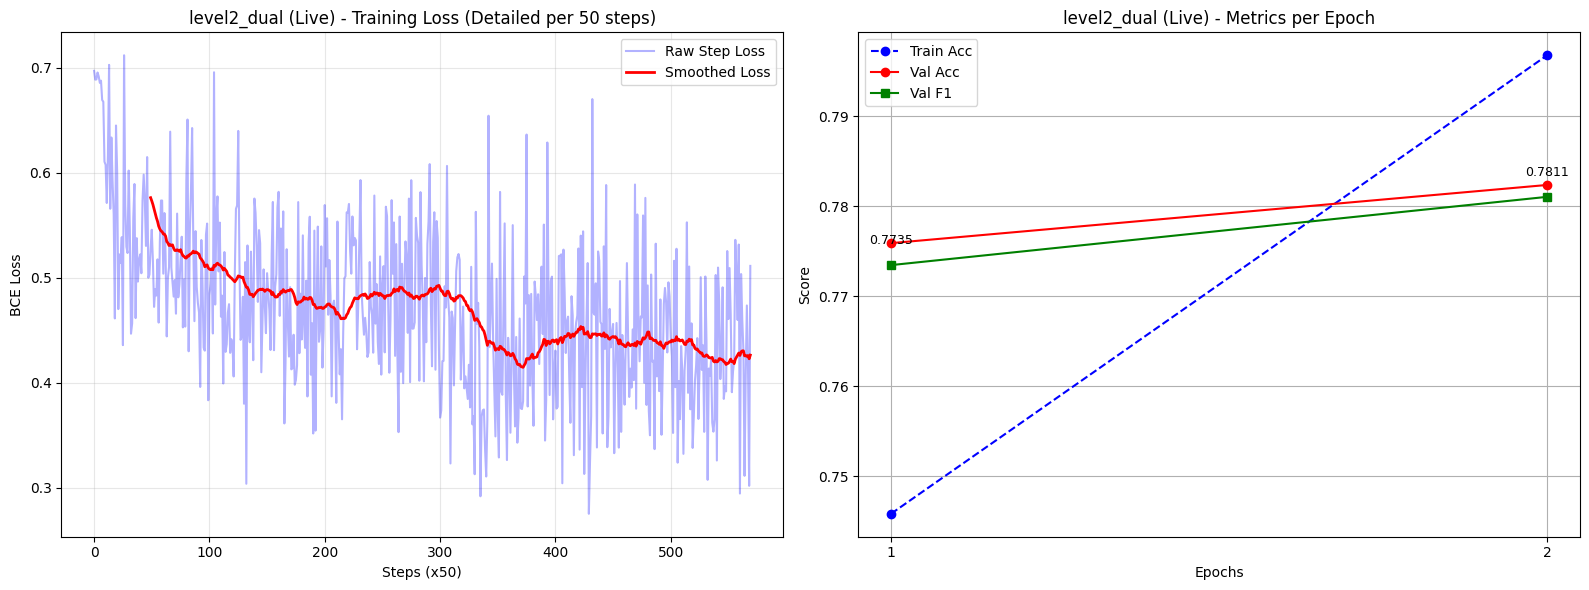

Epoch 2 Finished. Best F1 so far: 0.7811
--> Model Saved!

Training Complete! Best Val F1: 0.7811

Running Final Evaluation on Validation Set...


Evaluating:   0%|          | 0/1580 [00:00<?, ?it/s]

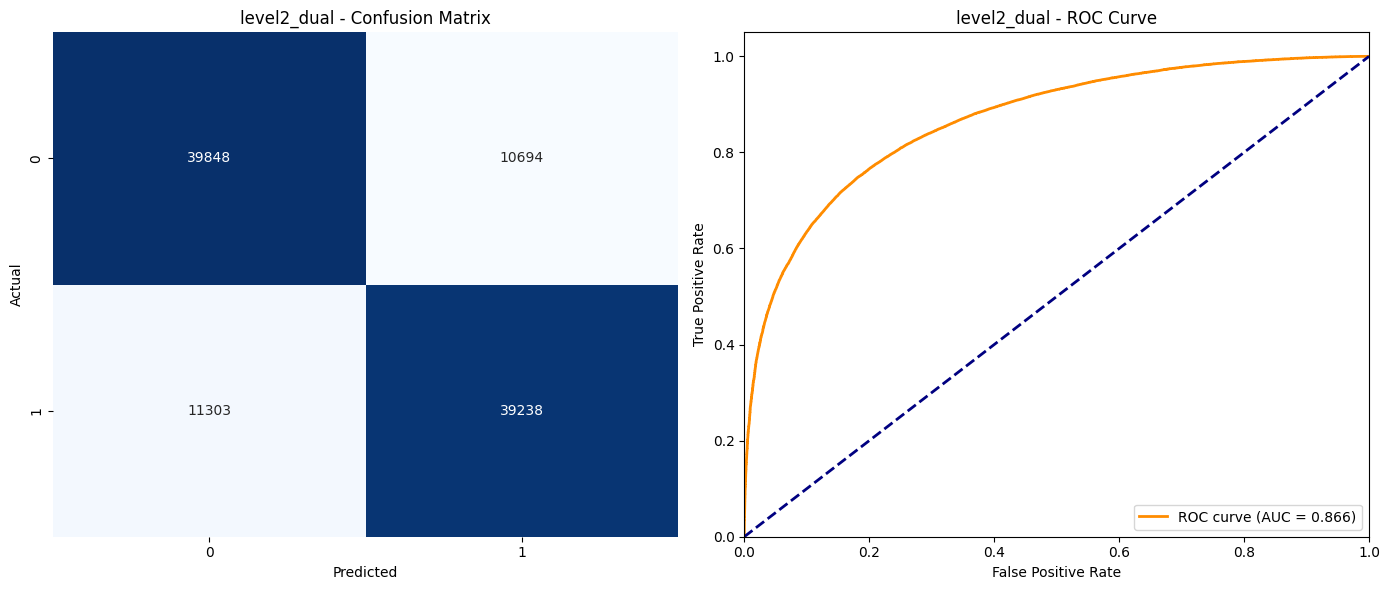


=== Classification Report ===
              precision    recall  f1-score   support

         0.0     0.7790    0.7884    0.7837     50542
         1.0     0.7858    0.7764    0.7811     50541

    accuracy                         0.7824    101083
   macro avg     0.7824    0.7824    0.7824    101083
weighted avg     0.7824    0.7824    0.7824    101083



In [ ]:
# EXECUTION
if __name__ == "__main__":
    DF_PATH = "/kaggle/input/cs213data/sarcasm.csv" 
    
    if os.path.exists(DF_PATH):
        print("Loading dataset...")
        df = pd.read_csv(DF_PATH)
        
        # --- Preprocessing ---
        print("Preprocessing text (this might take a while for 1M rows)...")
        df['comment'] = df['comment'].fillna("")
        df['parent_comment'] = df['parent_comment'].fillna("")
        df['comment_pp'] = df['comment'].apply(preprocess_text)
        df['parent_pp'] = df['parent_comment'].apply(preprocess_text)
        
        # --- Sentiment (Optional but needed for Level 3) ---
        # Lưu ý: Chạy TextBlob cho 1 triệu dòng sẽ khá lâu (15-30p). 
        # Nếu chỉ chạy Level 1 thì có thể comment đoạn này lại.
        print("Computing sentiment (Grab a coffee, this takes time)...")
        df['sentiment_comment'] = df['comment'].apply(compute_sentiment)
        df['sentiment_parent'] = df['parent_comment'].apply(compute_sentiment)
        
        # Init Tokenizer
        tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
        
        # --- RUN MODELS ---
        # Chọn Level bạn muốn chạy bằng cách bỏ comment
        
        # 1. Level 1: Comment Only
        # run_training(DistilBertBaseline, df, tokenizer, 'level1', 'level1_distilbert')
        
        # 2. Level 2: Comment + Parent
        run_training(DualDistilBert, df, tokenizer, 'level2', 'level2_dual')
        
        # 3. Level 3: Comment + Parent + Sentiment
        # run_training(DualDistilBertWithSentiment, df, tokenizer, 'level3', 'level3_dual_sent')
        
    else:
        print(f"Error: File not found at {DF_PATH}")

In [12]:
import gc
gc.collect()
torch.cuda.empty_cache()

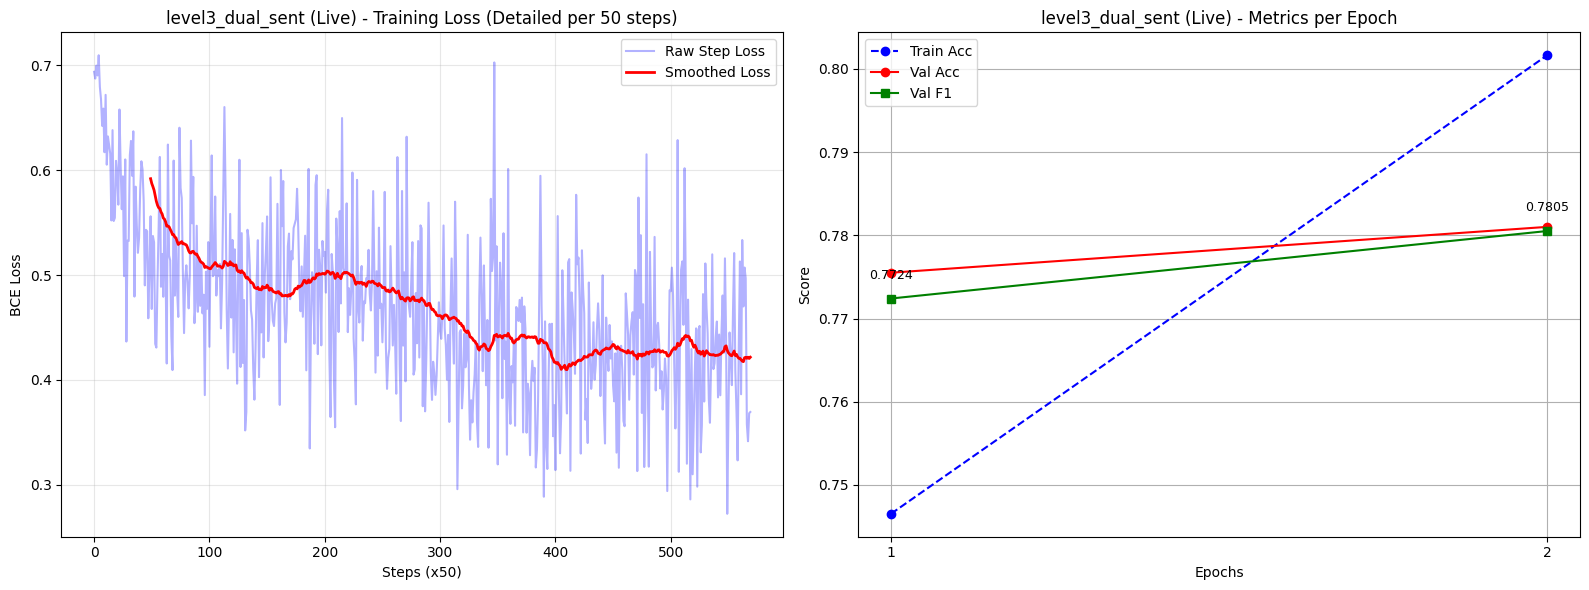

Epoch 2 Finished. Best F1 so far: 0.7805
--> Model Saved!

Training Complete! Best Val F1: 0.7805

Running Final Evaluation on Validation Set...


Evaluating:   0%|          | 0/1580 [00:00<?, ?it/s]

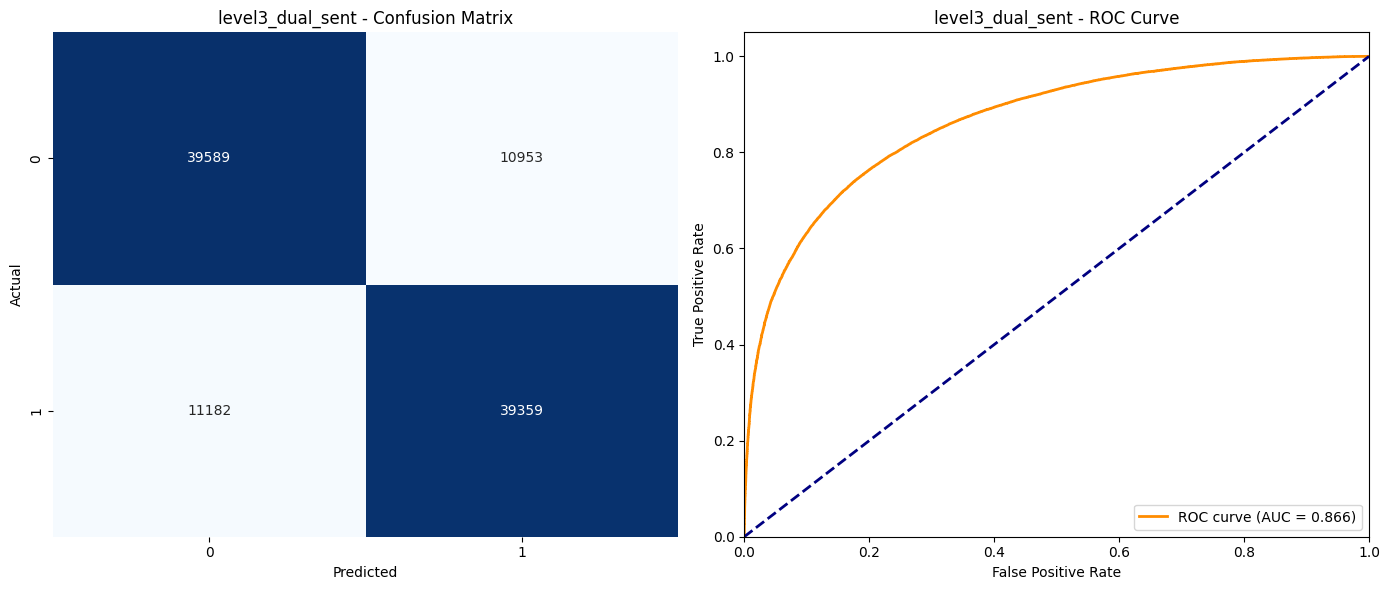


=== Classification Report ===
              precision    recall  f1-score   support

         0.0     0.7798    0.7833    0.7815     50542
         1.0     0.7823    0.7788    0.7805     50541

    accuracy                         0.7810    101083
   macro avg     0.7810    0.7810    0.7810    101083
weighted avg     0.7810    0.7810    0.7810    101083



In [13]:
# ==========================================
# 8. EXECUTION
# ==========================================
if __name__ == "__main__":
    DF_PATH = "/kaggle/input/cs213data/sarcasm.csv" 
    
    if os.path.exists(DF_PATH):
        print("Loading dataset...")
        df = pd.read_csv(DF_PATH)
        
        # --- Preprocessing ---
        print("Preprocessing text (this might take a while for 1M rows)...")
        df['comment'] = df['comment'].fillna("")
        df['parent_comment'] = df['parent_comment'].fillna("")
        df['comment_pp'] = df['comment'].apply(preprocess_text)
        df['parent_pp'] = df['parent_comment'].apply(preprocess_text)
        
        # --- Sentiment (Optional but needed for Level 3) ---
        # Lưu ý: Chạy TextBlob cho 1 triệu dòng sẽ khá lâu (15-30p). 
        # Nếu chỉ chạy Level 1 thì có thể comment đoạn này lại.
        print("Computing sentiment (Grab a coffee, this takes time)...")
        df['sentiment_comment'] = df['comment'].apply(compute_sentiment)
        df['sentiment_parent'] = df['parent_comment'].apply(compute_sentiment)
        
        # Init Tokenizer
        tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
        
        # --- RUN MODELS ---
        # Chọn Level bạn muốn chạy bằng cách bỏ comment
        
        # 1. Level 1: Comment Only
        # run_training(DistilBertBaseline, df, tokenizer, 'level1', 'level1_distilbert')
        
        # 2. Level 2: Comment + Parent
        # run_training(DualDistilBert, df, tokenizer, 'level2', 'level2_dual')
        
        # 3. Level 3: Comment + Parent + Sentiment
        run_training(DualDistilBertWithSentiment, df, tokenizer, 'level3', 'level3_dual_sent')
        
    else:
        print(f"Error: File not found at {DF_PATH}")